<a href="https://colab.research.google.com/github/Sumaiya-Era/Naive_Bayes_Classifier/blob/main/Na%C3%AFve_Bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing the libraries**

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Importing the dataset

In [48]:
dataset = pd.read_csv('https://raw.githubusercontent.com/Sumaiya-Era/Naive_Bayes_Classifier/refs/heads/main/IrisDataset.csv')
X = dataset.iloc[:,:4].values
y = dataset['species'].values

dataset.head(5)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


**Splitting the dataset into the Training set and Test set**

In [49]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)


**Feature Scaling**

In [50]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

**Naive Bayes from scratch (Gaussian Naive Bayes)**

In [97]:
class GaussianNB:
    def __init__(self, var_smoothing=1e-9):
        self.var_smoothing = var_smoothing
        self.classes_ = None
        self.class_count_ = None
        self.class_prior_ = None
        self.theta_ = None
        self.sigma_ = None

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        self.classes_, counts = np.unique(y, return_counts=True)
        self.class_count_ = counts
        n_classes = self.classes_.shape[0]
        n_features = X.shape[1]

        self.class_prior_ = counts / counts.sum()
        self.theta_ = np.zeros((n_classes, n_features))
        self.sigma_ = np.zeros((n_classes, n_features))

        for idx, c in enumerate(self.classes_):
            X_c = X[y == c]
            self.theta_[idx, :] = X_c.mean(axis=0)
            self.sigma_[idx, :] = X_c.var(axis=0, ddof=1) + self.var_smoothing

        return self

    def _joint_log_likelihood(self, X):
        X = np.atleast_2d(X)
        n_samples, n_features = X.shape
        n_classes = self.classes_.shape[0]
        mean = self.theta_[None, :, :]
        var = self.sigma_[None, :, :]
        X_expanded = X[:, None, :]

        log_likelihood_per_feature = -0.5 * (np.log(2.0 * np.pi * var) + ((X_expanded - mean) ** 2) / var)
        log_likelihood = log_likelihood_per_feature.sum(axis=2)
        log_prior = np.log(self.class_prior_)[None, :]
        joint_log_likelihood = log_prior + log_likelihood
        return joint_log_likelihood

    def predict_proba(self, X):
        jll = self._joint_log_likelihood(X)
        jll_max = np.max(jll, axis=1, keepdims=True)
        exp_scores = np.exp(jll - jll_max)
        probs = exp_scores / exp_scores.sum(axis=1, keepdims=True)
        return probs

    def predict(self, X):
        jll = self._joint_log_likelihood(X)
        idx = np.argmax(jll, axis=1)
        return self.classes_[idx]


**Training the Naive Bayes Classification model on the Training Set**

In [98]:
classifier = GaussianNB(var_smoothing=1e-8)
classifier.fit(X_train, y_train)

**Predicting the Test Set Results**

In [99]:
y_pred = classifier.predict(X_test)
y_pred

array(['setosa', 'versicolor', 'setosa', 'versicolor', 'setosa',
       'versicolor', 'virginica', 'setosa', 'setosa', 'versicolor',
       'virginica', 'versicolor', 'versicolor', 'virginica', 'versicolor',
       'virginica', 'virginica', 'versicolor', 'versicolor', 'setosa',
       'setosa', 'virginica', 'virginica', 'virginica', 'setosa',
       'versicolor', 'versicolor', 'virginica', 'setosa', 'setosa'],
      dtype=object)

**Model Evaluation(Performance Metrics)**

In [100]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
import seaborn as sns

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
cm = confusion_matrix(y_test, y_pred)

print("Accuracy      :", accuracy)
print("Precision     :", precision)
print("Recall        :", recall)
print("F1-Score      :", f1)
print("\nConfusion Matrix:")
print(cm)



Accuracy      : 0.9666666666666667
Precision     : 0.9696969696969697
Recall        : 0.9666666666666667
F1-Score      : 0.9665831244778613

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]


**Result Visualizatio**n

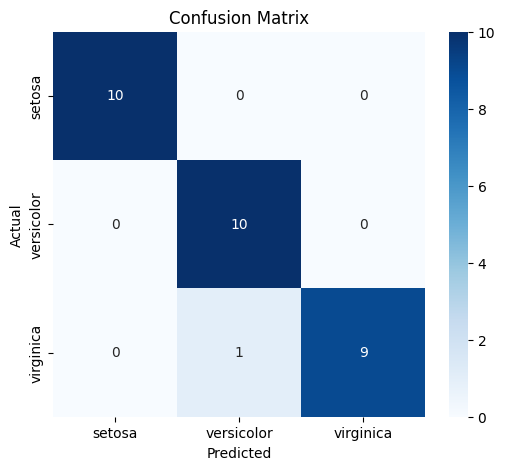

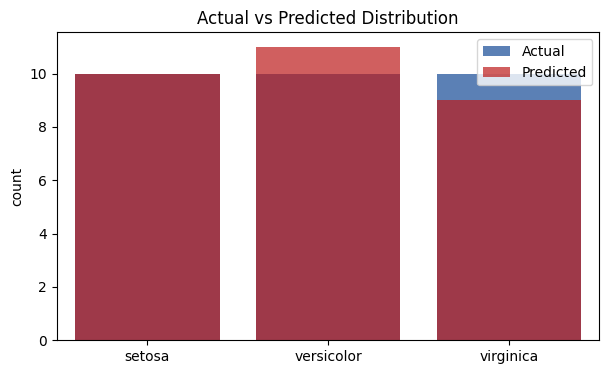

In [101]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=classifier.classes_,
            yticklabels=classifier.classes_,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# ---------- Predicted vs Actual Distribution ----------
plt.figure(figsize=(7, 4))
sns.countplot(x=y_test,   color="#0047AB", label="Actual", alpha=0.7)
sns.countplot(x=y_pred,   color="#D70000",  label="Predicted", alpha=0.7)
plt.title("Actual vs Predicted Distribution")
plt.legend(["Actual", "Predicted"])
plt.show()



**Comparing the Real Values with Predicted Values**

In [96]:
print("\nComparison of Actual vs Predicted:\n")
df = pd.DataFrame({'Actual Values':y_test.reshape(-1), 'Predicted Values':y_pred.reshape(-1)})
df


Comparison of Actual vs Predicted:



,Actual Values,Predicted Values
0,setosa,setosa
1,versicolor,versicolor
2,setosa,setosa
3,virginica,versicolor
4,setosa,setosa
5,versicolor,versicolor
6,virginica,virginica
7,setosa,setosa
8,setosa,setosa
9,versicolor,versicolor
